# Section 3 - Create quantum circuits

- Task 3.1: Construct dynamic circuits
- Task 3.2: Construct parameterized circuits
- Task 3.3: Transpile and optimize circuits
- Task 3.4: Construct basic quantum circuits

Official references used:
- https://quantum.cloud.ibm.com/docs/guides/construct-circuits
- https://quantum.cloud.ibm.com/docs/guides/classical-feedforward-and-control-flow
- https://quantum.cloud.ibm.com/docs/guides/transpile
- https://quantum.cloud.ibm.com/docs/guides/defaults-and-configuration-options

In [37]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister, Parameter, ParameterVector
from qiskit.circuit.library import HGate
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager

## Task 3.4 - Construct basic quantum circuits

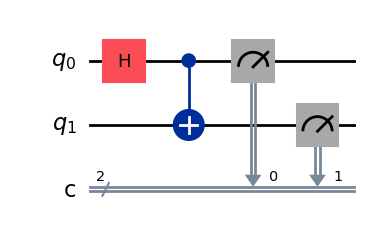

In [38]:
qc_basic = QuantumCircuit(2, 2, name="basic_example")
qc_basic.h(0)
qc_basic.cx(0, 1)
qc_basic.measure([0, 1], [0, 1])
qc_basic.draw("mpl")

Use append() for generic instruction insertion, and compose() to merge circuits.

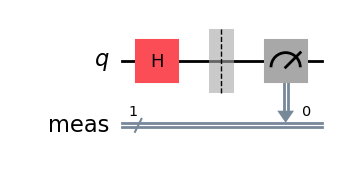

In [39]:
qc_append = QuantumCircuit(1)
qc_append.append(HGate(), [0])
qc_append.measure_all()
qc_append.draw("mpl")

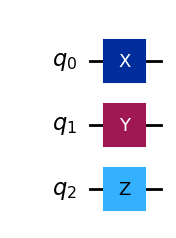

In [40]:
left = QuantumCircuit(3, name="left")
left.x(0)

right = QuantumCircuit(2, name="right")
right.y(0)
right.z(1)

combined = left.compose(right, qubits=[1, 2])
combined.draw("mpl")

In [41]:
print("depth:", combined.depth())
print("size:", combined.size())
print("count_ops:", combined.count_ops())

depth: 1
size: 3
count_ops: OrderedDict({'x': 1, 'y': 1, 'z': 1})


Measurement helpers:
- measure(): explicit qubit to classical-bit mapping
- measure_all(): measures all qubits (adds classical bits if needed)
- measure_active(): measures only non-idle qubits

Note that `cregbundle` is an option of `draw` that determine if the classical registers (creg) are split or merged (bundled)

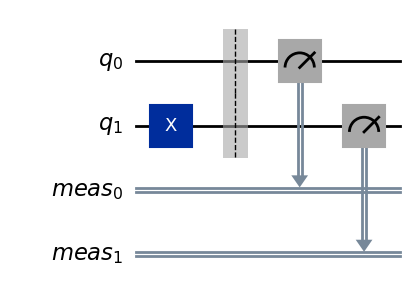

In [55]:
qc_measure_all = QuantumCircuit(2)
qc_measure_all.x(1)
qc_measure_all.measure_all()
qc_measure_all.draw("mpl", cregbundle=False)

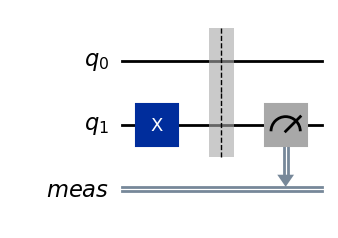

In [43]:
qc_measure_active = QuantumCircuit(2)
qc_measure_active.x(1)
qc_measure_active.measure_active()
qc_measure_active.draw("mpl", cregbundle=False)

## Task 3.2 - Construct parameterized circuits

Parameterized circuits use symbolic `Parameter` objects as gate angles. This lets you define a circuit template once and bind concrete values later.

- `Parameter("name")`: a single symbolic parameter
- `ParameterVector("name", n)`: a list-like collection of n parameters
- `assign_parameters(dict_or_list, inplace=False)`: returns a new circuit with values bound (use `inplace=True` to mutate in place)

Unbound parameters: ParameterView([Parameter(theta)])


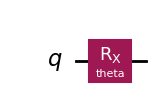

In [44]:
theta = Parameter("theta")
qc_param = QuantumCircuit(1)
qc_param.rx(theta, 0)

print("Unbound parameters:", qc_param.parameters)
qc_param.draw("mpl")

Original parameters after out-of-place binding: ParameterView([Parameter(theta)])
Bound copy parameters: ParameterView([])


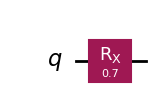

In [45]:
bound_copy = qc_param.assign_parameters({theta: 0.7}, inplace=False)

print("Original parameters after out-of-place binding:", qc_param.parameters)
print("Bound copy parameters:", bound_copy.parameters)
bound_copy.draw("mpl")

Vector parameters before binding: ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2])])
Vector parameters after binding: ParameterView([])


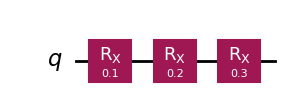

In [46]:
angles = ParameterVector("x", 3)
qc_vector = QuantumCircuit(1)
for a in angles:
    qc_vector.rx(a, 0)

qc_vector_bound = qc_vector.assign_parameters([0.1, 0.2, 0.3])
print("Vector parameters before binding:", qc_vector.parameters)
print("Vector parameters after binding:", qc_vector_bound.parameters)
qc_vector_bound.draw("mpl")

## Task 3.1 - Construct dynamic circuits

Dynamic circuits use control-flow context managers to embed classical logic directly into the circuit representation (not just Python-side unrolling):

- `with qc.if_test((clbit, value)):` — conditional block; use `as else_block:` to get an else branch
- `with qc.for_loop(range(n)):` — fixed-iteration loop inside the circuit
- `with qc.while_loop((clbit, value)):` — repeat while condition holds (requires mid-circuit measurement inside the body)

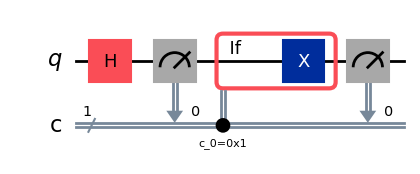

In [47]:
qreg = QuantumRegister(1, "q")
creg = ClassicalRegister(1, "c")
qc_if = QuantumCircuit(qreg, creg)
q0 = qreg[0]
c0 = creg[0]

qc_if.h(q0)
qc_if.measure(q0, c0)
with qc_if.if_test((c0, 1)):
    qc_if.x(q0)
qc_if.measure(q0, c0)
qc_if.draw("mpl")

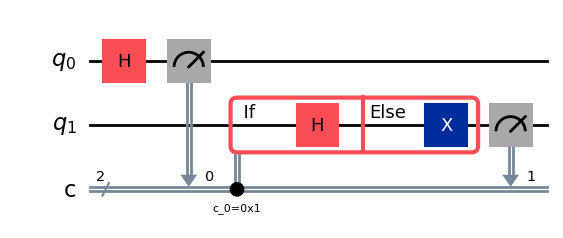

In [48]:
qreg2 = QuantumRegister(2, "q")
creg2 = ClassicalRegister(2, "c")
qc_if_else = QuantumCircuit(qreg2, creg2)
q0, q1 = qreg2
c0, c1 = creg2

qc_if_else.h(q0)
qc_if_else.measure(q0, c0)
with qc_if_else.if_test((c0, 1)) as else_block:
    qc_if_else.h(q1)
with else_block:
    qc_if_else.x(q1)
qc_if_else.measure(q1, c1)
qc_if_else.draw("mpl")

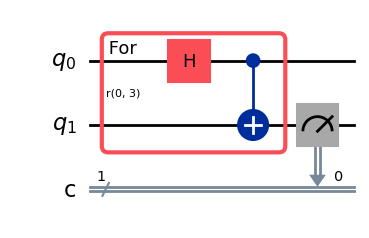

In [49]:
qc_for = QuantumCircuit(2, 1)
with qc_for.for_loop(range(3)):
    qc_for.h(0)
    qc_for.cx(0, 1)
qc_for.measure(1, 0)
qc_for.draw("mpl")

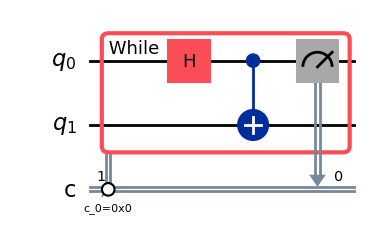

In [50]:
qc_while = QuantumCircuit(2, 1)
with qc_while.while_loop((qc_while.clbits[0], 0)):
    qc_while.h(0)
    qc_while.cx(0, 1)
    qc_while.measure(0, 0)
qc_while.draw("mpl")

## Task 3.3 - Transpile and optimize circuits

Transpilation converts an abstract circuit into one compatible with a target backend's gate set and qubit connectivity.

- `transpile(qc, backend, optimization_level=0..3)`: one-call convenience; level 0 = minimal, level 3 = heaviest optimization
- `generate_preset_pass_manager(backend=..., optimization_level=...)`: builds a reusable `StagedPassManager` that you invoke with `.run(qc)`
- Common options: `layout_method`, `routing_method` (e.g. `"sabre"`)

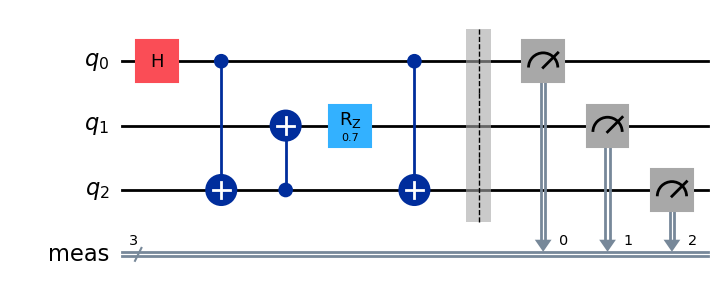

In [51]:
backend = GenericBackendV2(num_qubits=3)

qc_transpile = QuantumCircuit(3)
qc_transpile.h(0)
qc_transpile.cx(0, 2)
qc_transpile.cx(2, 1)
qc_transpile.rz(0.7, 1)
qc_transpile.cx(0, 2)
qc_transpile.measure_all()
qc_transpile.draw("mpl")

In [52]:
t0 = transpile(qc_transpile, backend=backend, optimization_level=0, seed_transpiler=42)
t3 = transpile(qc_transpile, backend=backend, optimization_level=3, seed_transpiler=42)

print("Original depth:", qc_transpile.depth(), "| size:", qc_transpile.size())
print("O0 depth:", t0.depth(), "| size:", t0.size())
print("O3 depth:", t3.depth(), "| size:", t3.size())

Original depth: 5 | size: 8
O0 depth: 7 | size: 10
O3 depth: 7 | size: 10


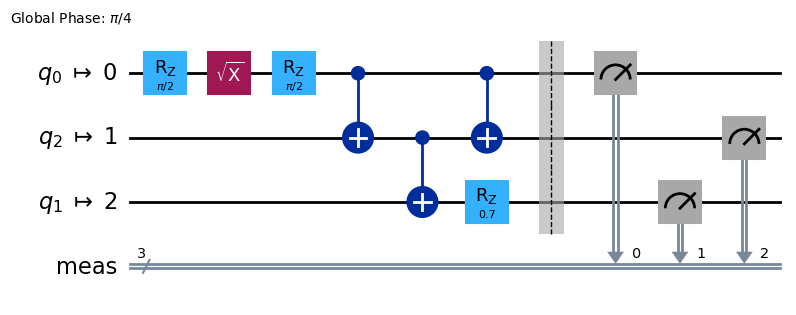

In [53]:
t3.draw("mpl", idle_wires=False)

Preset PM depth: 7
Preset PM count_ops: OrderedDict({'rz': 3, 'cx': 3, 'measure': 3, 'sx': 1, 'barrier': 1})


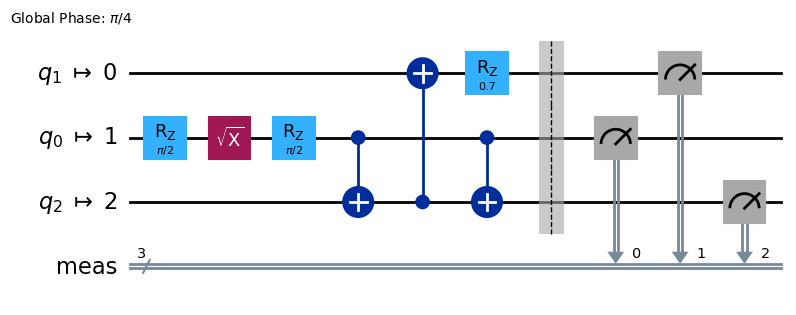

In [54]:
pm = generate_preset_pass_manager(
    optimization_level=2,
    backend=backend,
    layout_method="sabre",
    routing_method="sabre",
)

qc_pm = pm.run(qc_transpile)
print("Preset PM depth:", qc_pm.depth())
print("Preset PM count_ops:", qc_pm.count_ops())
qc_pm.draw("mpl", idle_wires=False)

## Quick exam checklist

- Use if_test / while_loop / for_loop for dynamic circuits.
- Use Parameter / ParameterVector + assign_parameters for parameterized circuits.
- Use transpile(..., optimization_level=0..3) for default compilation.
- Use generate_preset_pass_manager(...).run(circuit) for explicit pass-manager workflows.
- Use measure, measure_all, and measure_active correctly depending on the task.